In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from pymatgen.core import Composition, Element
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from mp_api.client import MPRester
import os

if os.path.exists('materials_data_6.csv'):
    df = pd.read_csv('materials_data_6.csv')
else:
    with MPRester ("4kQEE5SgbERcIS0ROBeFEyVkUof7kInE") as mpr:
        docs = mpr.materials.summary.search(
            band_gap=(0.1, 5.0),
            num_elements=(2, 5),
            fields=["material_id", "composition", "band_gap", "density",
                    "formation_energy_per_atom", "volume", "symmetry"])

    data = []
    for doc in docs:
        comp = Composition(doc.composition)
        avg_en = np.mean([Element(el).X for el in comp.elements]) # average electro negativity of the materials
        avg_ar = np.mean([Element(el).atomic_radius for el in comp.elements if Element(el).atomic_radius is not None])
        data.append({
            "band_gap": doc.band_gap,
            "density": doc.density,
            "formation_energy": doc.formation_energy_per_atom,
            "avg_electroneg": avg_en,
            "avg_atomic_radius": avg_ar,
            "spacegroup": doc.symmetry.crystal_system if doc.symmetry else "unknown",
        })
    df = pd.DataFrame(data)
    print(df.shape)
    df.to_csv("materials_data_6.csv", index=False)
    df.head()

c:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

df_encoded = pd.get_dummies(df, columns = ['spacegroup'], drop_first =True)
df_clean = df_encoded.dropna()

X = df_clean.drop(['band_gap'], axis=1)
y = df_clean['band_gap']

# Train-val-test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Training_set:{X_train.shape}")
print(f"Validation_set:{X_val.shape}")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Mean-absolute-error: {mae:.3f} eV")
print(f"R2 Score: {r2:.3f}") # we obtained a low 0.473 R2 score for the baseline model, this suggests that we need more impactful features
print(f"Features used: {X_train.shape[1]}")


Training_set:(40645, 10)
Validation_set:(13549, 10)
Mean-absolute-error: 0.699 eV
R2 Score: 0.475
Features used: 10


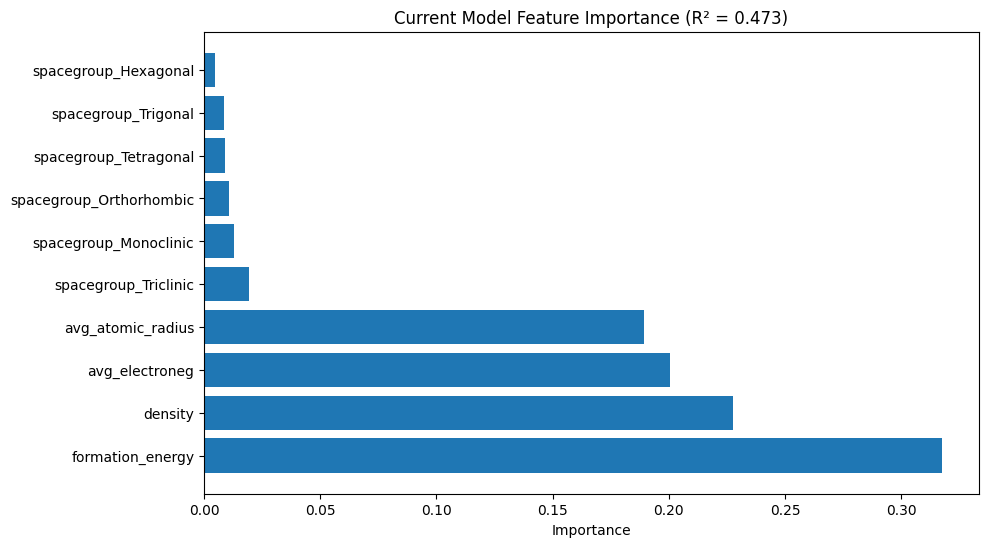

In [10]:
feature_cols = X_train.columns.tolist()
feature_importance = pd.DataFrame({'feature':feature_cols, 
                                   'importance':rf.feature_importances_}
                                   ).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Current Model Feature Importance (R² = 0.473)')
plt.tight_layout
plt.show()

In [11]:
# Retrieve new data from Materials Project database for new features
def add_features():
    with MPRester ("4kQEE5SgbERcIS0ROBeFEyVkUof7kInE") as mpr:
        docs = mpr.materials.summary.search(
            band_gap=(0.1, 5.0),
            num_elements=(2, 5),
            fields=["composition", "volume","nsites"])

    additional_data=[]

    for doc in docs:
        comp = Composition(doc.composition)

        volume_per_atom = doc.volume/doc.nsites if doc.nsites else np.nan

        periods=[]
        groups=[]
        atomic_numbers=[]

        for el in comp.elements:
            element_obj = Element(el)
            periods.append(element_obj.row)
            groups.append(element_obj.group if element_obj.group else 0)
            atomic_numbers.append(element_obj.Z if element_obj.Z else 0)
            
        # Calculate statistics
        avg_period = np.mean(periods) if periods else np.nan
        std_period = np.std(periods) if periods else np.nan
        avg_group = np.mean(groups) if groups else np.nan
        std_group = np.std(groups) if groups else np.nan
        avg_Z = np.mean(atomic_numbers) if atomic_numbers else np.nan


        additional_data.append({
            "volume_per_atom": volume_per_atom,
            "avg_period": avg_period,
            "std_period": std_period,
            "avg_group": avg_group,
            "std_group": std_group,
            "avg_Z": avg_Z,
            "nsites": doc.nsites,
            "composition_string": str(comp)
        })
    df_additional = pd.DataFrame(additional_data)
    # Add interaction features
    df_additional['formation_density_ratio'] = df['formation_energy']/df['density']
    df_additional['formation_electroneg_product'] = df['formation_energy'] * df['avg_electroneg']
    df_additional['density_radius_product'] = df['density'] * df['avg_atomic_radius']
    df_additional['formation_volume_energy'] = df['formation_energy'] * df_additional['volume_per_atom']
    df_temp = df.drop(["spacegroup", 'band_gap'], axis=1)
    X = pd.concat([df_temp, df_additional], axis=1)
    X.to_csv("materials_data_16.csv", index=False)
    return X


In [12]:
# Add the additonal 12 features to the original data set and drop space group since it has low importance

if os.path.exists('materials_data_16.csv'):
    X = pd.read_csv("materials_data_16.csv")
    X_num = X.select_dtypes(include=[np.number])
else:
    X = add_features()
    X_num = X.select_dtypes(include=[np.number])


In [13]:
# Recreate the 3 fold split with new data set

X_temp, X_test, y_temp, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"\nNew splits:")
print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")


New splits:
Training: (40645, 15)
Validation: (13549, 15)
Test: (13549, 15)



BASELINE WITH ENHANCED FEATURES
R²: 0.522
MAE: 0.670 eV
Features used: 15


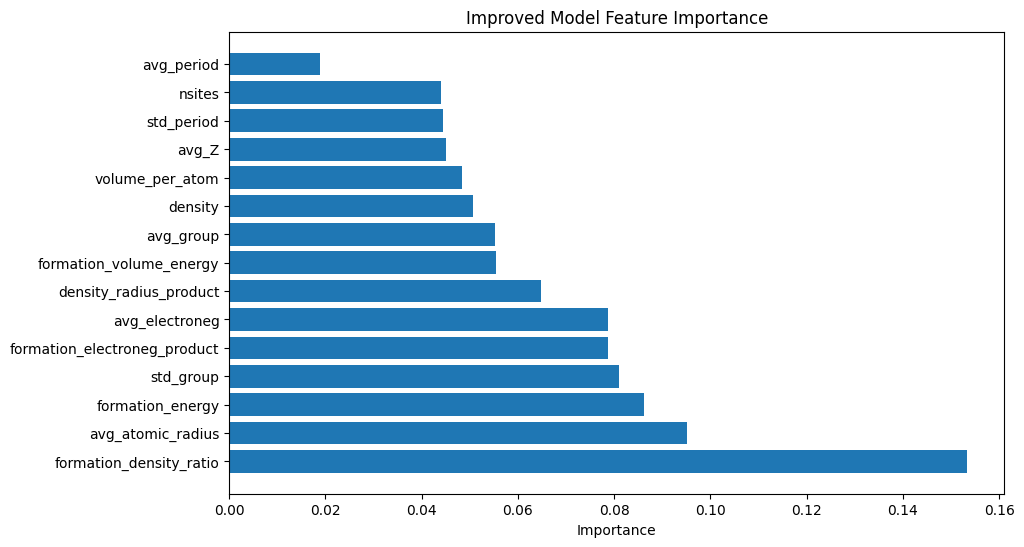

In [14]:
# Train baseline model with new features

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate

y_pred_val = rf.predict(X_val)
r2 = r2_score(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)

print(f"\n{'='*50}")
print("BASELINE WITH ENHANCED FEATURES")
print(f"{'='*50}")
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f} eV")
print(f"Features used: {X_train.shape[1]}")

# Show feature importance to verify improvements

feature_cols_new = X_train.columns.tolist()
importance_df = pd.DataFrame({
    'feature': feature_cols_new,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:16], importance_df['importance'][:16])
plt.xlabel('Importance')
plt.title('Improved Model Feature Importance')
plt.tight_layout
plt.show()

In [15]:
# Drop features with very low importance

low_importance_features = ['avg_period']

reduced_features = [col for col in feature_cols_new if col not in low_importance_features]
X_reduced = X[reduced_features]

# Retrain and see if R² improves

X_temp, X_test, y_temp, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

rf_reduced = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reduced.fit(X_train, y_train)
r2_reduced = r2_score(y_val, rf_reduced.predict(X_val))

print(f"R² after removing low-importance features: {r2_reduced:.3f}")

#Excellent: R² > 0.85, MAE < 0.2 eV (DFT-level accuracy)
#Good: R² > 0.70, MAE < 0.4 eV
#Decent: R² > 0.50, MAE < 0.6 eV
#Needs work: R² < 0.50, MAE > 0.6 eV 

R² after removing low-importance features: 0.522


In [ ]:
# Since RandomForest performs the best, we try to optimize performance by tunning the hyperparameters

from sklearn.model_selection import GridSearchCV

# Simple hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Use fewer combinations for speed
grid_search = GridSearchCV(
    rf_base, param_grid, 
    cv=3, scoring='r2', 
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

# Evaluate best model
best_rf = grid_search.best_estimator_
y_pred_val = best_rf.predict(X_val)
r2_tuned = r2_score(y_val, y_pred_val)
print(f"Validation R² after tuning: {r2_tuned:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': None, 'n_estimators': 300}
Best CV R²: 0.4862
Validation R² after tuning: 0.5246


In [17]:
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=1, min_samples_split=2 , random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate

y_pred_val = rf.predict(X_val)
r2 = r2_score(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)

print(f"\n{'='*50}")
print("BASELINE WITH ENHANCED FEATURES AND HYPERPARAMETER TUNNING")
print(f"{'='*50}")
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f} eV")
print(f"Features used: {X_train.shape[1]}")


BASELINE WITH ENHANCED FEATURES AND HYPERPARAMETER TUNNING
R²: 0.525
MAE: 0.667 eV
Features used: 14


In [18]:
# Retrieve new high impact data from Materials Project database for new features

def add_high_impact_features(df):

    electroneg_range=[]
    radius_mismatch=[]
    period_diversity=[]

    for idx, row in df.iterrows():
        comp = Composition(row['composition_string'])

        electronegativities =[]
        atomic_radii=[]
        periods=[]

        for el in comp.elements:
            element_obj = Element(el)

            # Electronegativity
            if element_obj.X is not None:
                electronegativities.append(element_obj.X)
            
            # Atomic radius
            radius = element_obj.atomic_radius
            if radius is not None:
                try:
                    atomic_radii.append(float(radius))
                except:
                    pass
            
            # Period
            periods.append(element_obj.row)
        
        # Calculate features
        if electronegativities:
            electroneg_range.append(np.max(electronegativities) - np.min(electronegativities))
        else:
            electroneg_range.append(np.nan)
        
        if atomic_radii and np.mean(atomic_radii) > 0:
            radius_mismatch.append(np.std(atomic_radii) / np.mean(atomic_radii))
        else:
            radius_mismatch.append(np.nan)
        
        if periods:
            period_diversity.append(len(set(periods)))
        else:
            period_diversity.append(np.nan)
    
    # Add to dataframe
    df['electroneg_range'] = electroneg_range
    df['radius_mismatch'] = radius_mismatch
    df['period_diversity'] = period_diversity
    df.to_csv('materials_data_19.csv', index=False)
    return df
if os.path.exists('materials_data_19.csv'):
    X_19 = pd.read_csv("materials_data_19.csv")
    X_numerical = X_19.select_dtypes(include=[np.number])
else:
    X_19 = add_high_impact_features(X)
    X_numerical = X_19.select_dtypes(include=[np.number])


In [19]:
# Recreate the 3 fold split with new data set

X_temp, X_test, y_temp, y_test = train_test_split(X_numerical, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"\nNew splits:")
print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")


New splits:
Training: (40645, 18)
Validation: (13549, 18)
Test: (13549, 18)


In [20]:
# Train
current_features = X_train.columns.to_list()
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=1, min_samples_split=2 , random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

print(f"\n{'='*50}")
print("PERFORMANCE WITH HIGH-IMPACT FEATURES")
print(f"{'='*50}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f} eV")
print(f"Features: {len(current_features)}")


PERFORMANCE WITH HIGH-IMPACT FEATURES
R²: 0.5386
MAE: 0.6557 eV
Features: 18


In [41]:
def add_more_features(X_19):
    with MPRester("4kQEE5SgbERcIS0ROBeFEyVkUof7kInE") as mpr:
        docs = mpr.materials.summary.search(
            band_gap=(0.1, 5.0),
            num_elements=(2, 5),
            fields=["band_gap", "efermi", "total_magnetization"])

    data = []
    for doc in docs:
        efermi = doc.efermi if hasattr(doc, 'efermi') and doc.efermi is not None else np.nan
        is_magnetic = 1 if (hasattr(doc, 'total_magnetization') and 
                            doc.total_magnetization and 
                            abs(doc.total_magnetization) > 0.01) else 0
        
        data.append({"efermi": efermi,"is_magnetic": is_magnetic, "band_gap":doc.band_gap})
    df_more = pd.DataFrame(data)
    df_more['efermi_formation'] = df_more['efermi'] * X_19['formation_energy']  # New interaction
    df_more['density_efermi'] = X_19['density'] * df_more['efermi']  # New interaction
    X = pd.concat([df_more, X_19], axis=1)
    return X
if os.path.exists('materials_data_23.csv'):
    X_23 = pd.read_csv("materials_data_23.csv")
    clean_mask = ~(X_23.isna().any(axis=1) | y.isna())
    X_clean = X_23[clean_mask]
    y_clean = y[clean_mask]
    X_numerical = X_clean.select_dtypes(include=[np.number])
else:
    X_temporary = add_more_features(X_19)
    X_clean = X_temporary.dropna()
    y = X_clean['band_gap']
    X_23 = X_clean.drop(['band_gap'], axis=1)
    X_23.to_csv('materials_data_23.csv', index=False)
    X_numerical = X_23.select_dtypes(include=[np.number])

In [42]:
# Recreate the 3 fold split with new data set
X_temp, X_test, y_temp, y_test = train_test_split(X_numerical, y_clean, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"\nNew splits:")
print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")


New splits:
Training: (40627, 22)
Validation: (13543, 22)
Test: (13543, 22)


In [44]:
# Train
current_features = X_train.columns.to_list()
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=1, min_samples_split=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

print(f"\n{'='*50}")
print("PERFORMANCE WITH HIGH-IMPACT FEATURES")
print(f"{'='*50}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f} eV")
print(f"Features: {len(current_features)}")


PERFORMANCE WITH HIGH-IMPACT FEATURES
R²: 0.5600
MAE: 0.6404 eV
Features: 22


In [24]:
# Test set performace

y_pred_test = rf.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"\nTest Set (Unseen Data):")
print(f"  R²: {test_r2:.4f}")
print(f"  MAE: {test_mae:.4f} eV")


Test Set (Unseen Data):
  R²: 0.5533
  MAE: 0.6487 eV


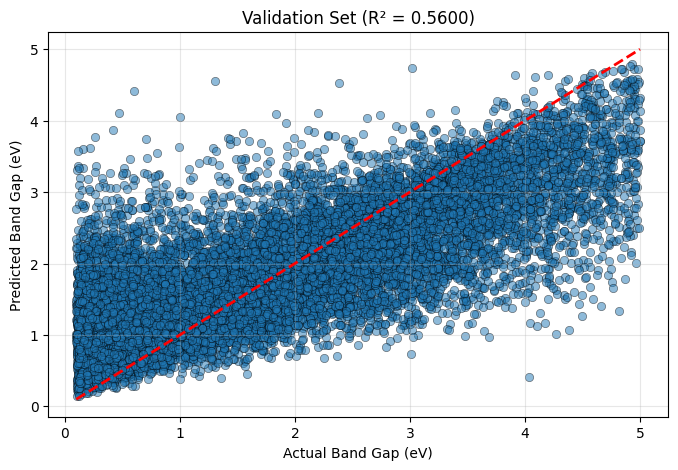

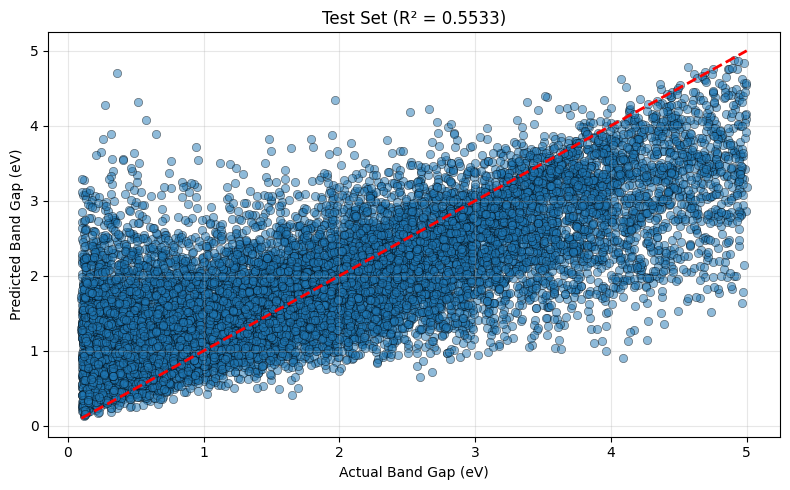

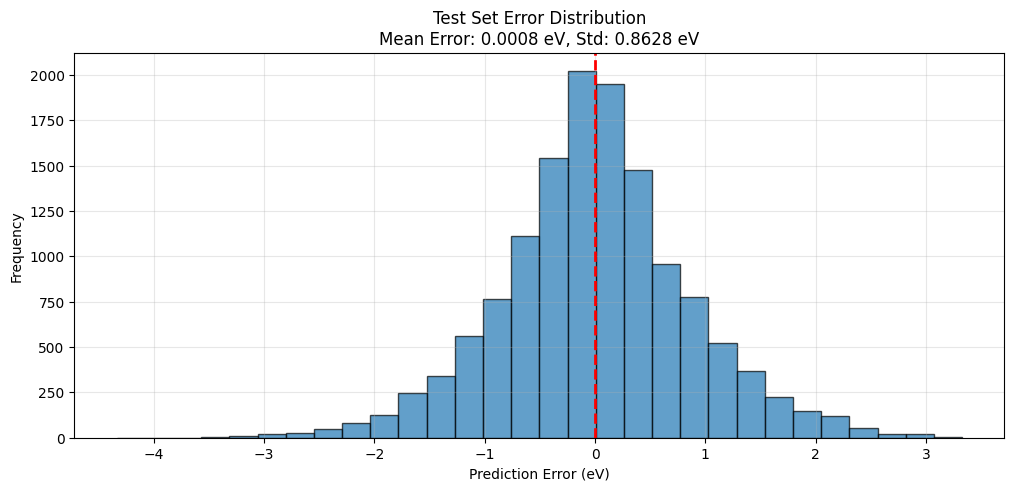

In [25]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

# Plot 1: Validation set predictions
ax1.scatter(y_val, y_pred, alpha=0.5, edgecolors='black', linewidth=0.5)
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Band Gap (eV)')
ax1.set_ylabel('Predicted Band Gap (eV)')
ax1.set_title(f'Validation Set (R² = {r2:.4f})')
ax1.grid(True, alpha=0.3)

# Plot 2: Test set predictions
fig, ax2 = plt.subplots(1, 1, figsize=(8, 5))
ax2.scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidth=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Band Gap (eV)')
ax2.set_ylabel('Predicted Band Gap (eV)')
ax2.set_title(f'Test Set (R² = {test_r2:.4f})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error distribution
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
errors_test = y_test - y_pred_test
ax.hist(errors_test, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Prediction Error (eV)')
ax.set_ylabel('Frequency')
ax.set_title(f'Test Set Error Distribution\nMean Error: {errors_test.mean():.4f} eV, Std: {errors_test.std():.4f} eV')
ax.grid(True, alpha=0.3)
plt.show()

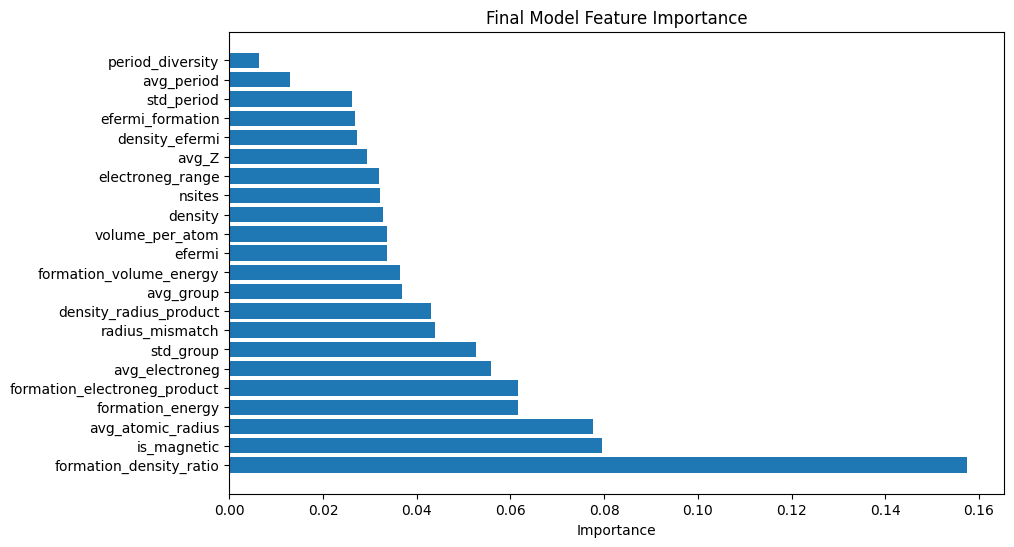

In [26]:
importance_df = pd.DataFrame({
    'feature': current_features,
    'importance':rf.feature_importances_
    }).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:23], importance_df['importance'][:23])
plt.xlabel('Importance')
plt.title('Final Model Feature Importance')
plt.tight_layout
plt.show()

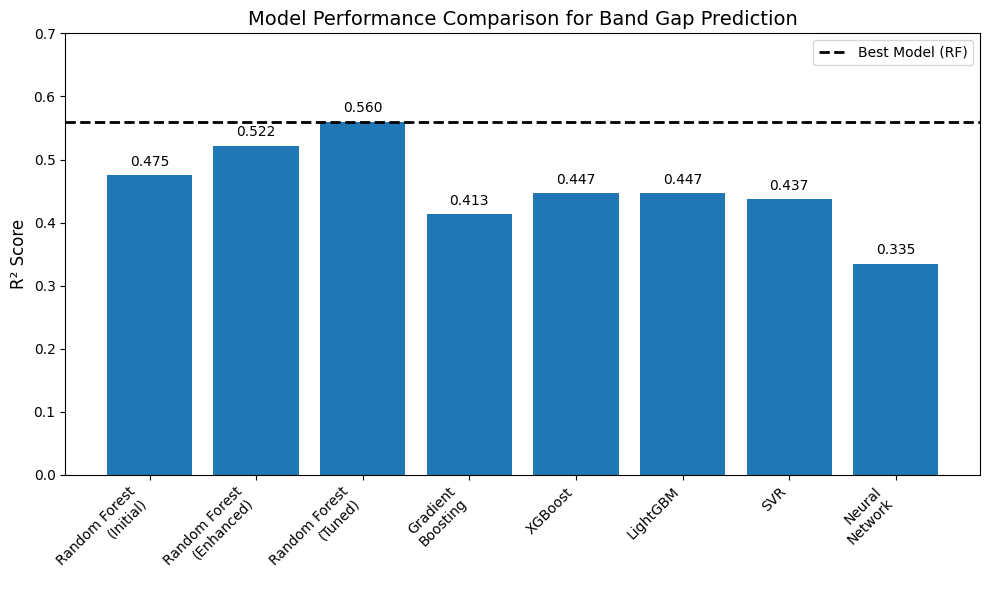

In [27]:
# Model Comparison Plot
import matplotlib.pyplot as plt
models = ['Random Forest\n(Initial)', 'Random Forest\n(Enhanced)', 
          'Random Forest\n(Tuned)', 'Gradient\nBoosting', 
          'XGBoost', 'LightGBM', 'SVR', 'Neural\nNetwork']
r2_scores = [0.475, 0.522, 0.560, 0.413, 0.447, 0.447, 0.437, 0.335]

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#FFB347', '#4ECDC4', '#95A5A6', '#95A5A6', '#95A5A6', '#95A5A6', '#95A5A6']
bars = plt.bar(models, r2_scores,  linewidth=1.5)
plt.axhline(y=0.56, color='black', linestyle='--', linewidth=2, label='Best Model (RF)')
plt.ylabel('R² Score', fontsize=12)
plt.title('Model Performance Comparison for Band Gap Prediction', fontsize=14)
plt.ylim(0, 0.7)
plt.xticks(rotation=45, ha='right')
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)
r2_gb = r2_score(y_val, gb.predict(X_val))

print(f"Gradient Boosting R²: {r2_gb:.4f}")
print(f"Improvement over RF: +{r2_gb - 0.5598:.4f}")

Gradient Boosting R²: 0.4132
Improvement over RF: +-0.1466


Optimal number of features: 22
Features kept: ['efermi', 'is_magnetic', 'efermi_formation', 'density_efermi', 'density', 'formation_energy', 'avg_electroneg', 'avg_atomic_radius', 'volume_per_atom', 'avg_period', 'std_period', 'avg_group', 'std_group', 'avg_Z', 'nsites', 'formation_density_ratio', 'formation_electroneg_product', 'density_radius_product', 'formation_volume_energy', 'electroneg_range', 'radius_mismatch', 'period_diversity']
Features removed: []


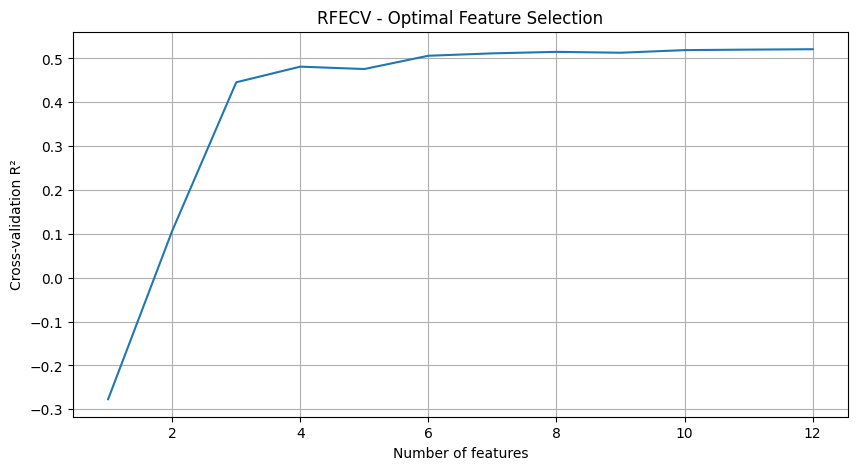


Original RF R²: 0.5598
RF with feature selection R²: 0.5600
Improvement: +0.0002


In [29]:
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt

# Use RFE to find optimal features
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rfecv = RFECV(
    estimator=rf_selector,
    step=2,  # Remove 2 features at a time
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Features kept: {X_train.columns[rfecv.support_].tolist()}")
print(f"Features removed: {X_train.columns[~rfecv.support_].tolist()}")

# Plot feature selection
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'])
plt.xlabel('Number of features')
plt.ylabel('Cross-validation R²')
plt.title('RFECV - Optimal Feature Selection')
plt.grid(True)
plt.show()

# Train on selected features
X_train_sel = rfecv.transform(X_train)
X_val_sel = rfecv.transform(X_val)

rf_sel = RandomForestRegressor(n_estimators=300,max_depth=None, min_samples_leaf=1, min_samples_split=2, random_state=42, n_jobs=-1)
rf_sel.fit(X_train_sel, y_train)
r2_sel = r2_score(y_val, rf_sel.predict(X_val_sel))

print(f"\nOriginal RF R²: 0.5598")
print(f"RF with feature selection R²: {r2_sel:.4f}")
print(f"Improvement: +{r2_sel - 0.5598:.4f}")

In [30]:
from scipy import stats

outlier_mask = ((X_numerical['formation_energy'] > -5) & (X_numerical['formation_energy'] < 0) &  # Reasonable energy
    (X_numerical['density'] > 0) & (X_numerical['density'] < 20))

X_numerical_clean = X_numerical[outlier_mask]
y_clean_outliers = y_clean[outlier_mask]

print(f"Kept {len(X_numerical_clean)} out of {len(X_numerical)} samples")
print(f"Aligned? {X_numerical_clean.index.equals(y_clean_outliers.index)}") 

# Recreate the 3 fold split with new data set
X_temp, X_test, y_temp, y_test = train_test_split(X_numerical_clean, y_clean_outliers, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"\nNew splits:")
print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Kept 66051 out of 67713 samples
Aligned? True

New splits:
Training: (39630, 22)
Validation: (13210, 22)
Test: (13211, 22)


In [31]:
# Ensemble multiple Random Forests (more stable than RF+GB)
rf1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2 = RandomForestRegressor(n_estimators=100, random_state=123)
rf3 = RandomForestRegressor(n_estimators=100, random_state=456)

rf1.fit(X_train, y_train)
rf2.fit(X_train, y_train)
rf3.fit(X_train, y_train)

# Average predictions
pred1 = rf1.predict(X_val)
pred2 = rf2.predict(X_val)
pred3 = rf3.predict(X_val)

ensemble_pred = (pred1 + pred2 + pred3) / 3
r2_ensemble = r2_score(y_val, ensemble_pred)

print(f"Single RF R²: 0.560")
print(f"Ensemble (3 RFs) R²: {r2_ensemble:.4f}")
print(f"Improvement: +{r2_ensemble - 0.560:.4f}")

Single RF R²: 0.560
Ensemble (3 RFs) R²: 0.5567
Improvement: +-0.0033


In [32]:
# Train
current_features = X_train.columns.to_list()
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=1, min_samples_split=2 , random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

print(f"\n{'='*50}")
print("PERFORMANCE WITH HIGH-IMPACT FEATURES")
print(f"{'='*50}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f} eV")
print(f"Features: {len(current_features)}")


PERFORMANCE WITH HIGH-IMPACT FEATURES
R²: 0.5555
MAE: 0.6471 eV
Features: 22


In [33]:
# Continue using the data set before cleaning outliers, ensemble and gradient boosting

oxide_mask = X_clean['composition_string'].str.contains('O', na=False)

df_oxides = X_clean[oxide_mask]
y_oxides = y_clean[oxide_mask]

print(f"Original dataset: {len(X_clean)} materials")
print(f"Oxides only: {len(df_oxides)} materials")
print(f"df_oxides shape: {df_oxides.shape}")
print(f"y_oxides shape: {y_oxides.shape}")

Original dataset: 67713 materials
Oxides only: 48389 materials
df_oxides shape: (48389, 23)
y_oxides shape: (48389,)


In [34]:
def add_oxide_features(df_oxides):
    """Add oxide-specific features using existing data"""
    
    # 2.1: Oxygen fraction (from composition_string)
    oxygen_fraction = []
    for idx, row in df_oxides.iterrows():
        comp_str = row['composition_string']
        # Simple count of oxygen atoms
        o_count = comp_str.count('O')
        # Rough total atoms count
        total_atoms = len(comp_str.replace(' ', ''))
        oxygen_fraction.append(o_count / total_atoms if total_atoms > 0 else 0)
    df_oxides['oxygen_fraction'] = oxygen_fraction
    
    # 2.2: Metal-oxygen electronegativity difference (using avg_electroneg)
    # Oxygen electronegativity = 3.44 (Pauling scale)
    df_oxides['metal_oxygen_electroneg_diff'] = abs(df_oxides['avg_electroneg'] - 3.44)
    
    # 2.3: Formation energy per oxygen (using formation_energy)
    df_oxides['formation_per_oxygen'] = df_oxides['formation_energy'] / df_oxides['oxygen_fraction']
    
    # 2.4: Density * oxygen fraction (using density)
    df_oxides['density_oxygen_product'] = df_oxides['density'] * df_oxides['oxygen_fraction']
    
    # 2.5: Band gap proxy (formation_energy * oxygen_fraction)
    df_oxides['band_gap_proxy'] = df_oxides['formation_energy'] * df_oxides['oxygen_fraction']
    df_oxides.to_csv('materials_data_28.csv', index=False)
    return df_oxides

if os.path.exists('materials_data_28.csv'):
    df_oxides = pd.read_csv("materials_data_28.csv")
    df_numerical = df_oxides.select_dtypes(include=[np.number])
else:
    df_oxides = add_oxide_features(df_oxides)
    df_numerical = df_oxides.select_dtypes(include=[np.number])


In [35]:
# Recreate the 3 fold split with new data set

X_temp, X_test, y_temp, y_test = train_test_split(df_numerical, y_oxides, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"\nNew splits:")
print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")


New splits:
Training: (29033, 27)
Validation: (9678, 27)
Test: (9678, 27)


In [36]:
# Train
rf_oxides = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_oxides.fit(X_train, y_train)

# Evaluate
y_pred = rf_oxides.predict(X_val)
r2_oxides = r2_score(y_val, y_pred)
mae_oxides = mean_absolute_error(y_val, y_pred)

print(f"\n{'='*50}")
print("OXIDES-ONLY PERFORMANCE (No New API Calls)")
print(f"{'='*50}")
print(f"R²: {r2_oxides:.4f}")
print(f"MAE: {mae_oxides:.4f} eV")


OXIDES-ONLY PERFORMANCE (No New API Calls)
R²: 0.5512
MAE: 0.6622 eV


In [37]:
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# XGBoost needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Try different parameters for oxides
xgb_params = [
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03},
    {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1},
]

print("XGBoost on Oxides:")
for params in xgb_params:
    xgb = XGBRegressor(**params, random_state=42, verbosity=0)
    xgb.fit(X_train_scaled, y_train)
    r2 = r2_score(y_val, xgb.predict(X_val_scaled))
    print(f"  {params}: R² = {r2:.4f}")

XGBoost on Oxides:
  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}: R² = 0.3330
  {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03}: R² = 0.3799
  {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1}: R² = 0.4682


In [38]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)
r2_lgbm = r2_score(y_val, lgbm.predict(X_val))
print(f"LightGBM R²: {r2_lgbm:.4f}")

LightGBM R²: 0.4471


In [39]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR needs scaled features and works well for small datasets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

svr_params = [
    {'kernel': 'rbf', 'C': 1.0, 'epsilon': 0.1},
    {'kernel': 'rbf', 'C': 10.0, 'epsilon': 0.1},
    {'kernel': 'linear', 'C': 1.0},
]

print("SVR on Oxides:")
for params in svr_params:
    svr = SVR(**params)
    svr.fit(X_train_scaled, y_train)
    r2 = r2_score(y_val, svr.predict(X_val_scaled))
    print(f"  {params}: R² = {r2:.4f}")

SVR on Oxides:
  {'kernel': 'rbf', 'C': 1.0, 'epsilon': 0.1}: R² = 0.4074
  {'kernel': 'rbf', 'C': 10.0, 'epsilon': 0.1}: R² = 0.4367
  {'kernel': 'linear', 'C': 1.0}: R² = 0.2546


In [40]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train, y_train)
r2_mlp = r2_score(y_val, mlp.predict(X_val))
print(f"Neural Network R²: {r2_mlp:.4f}")

Neural Network R²: 0.3353
